Hospital Readmission Prediction: Decision Tree vs Random Forest

In this notebook, we compare two classification models for predicting whether a patient will be readmitted within 30 days:

- Decision Tree Classifier
- Random Forest Classifier

The goal is to evaluate how both models perform on the same dataset and understand the trade-off between interpretability and predictive performance.

1. Project Objective

Hospital readmissions are an important healthcare problem because they may indicate complications in patient recovery and can increase hospital costs.

The objective of this project is to build machine learning models that predict whether a patient will be readmitted within 30 days based on available clinical and administrative features.

We will:
- prepare the dataset,
- encode categorical variables,
- train a Decision Tree model,
- train a Random Forest model,
- compare their results using accuracy and classification metrics.

2. Dataset Description

The dataset used in this project is `hospital_readmissions_30k.csv`.

It contains patient-related information such as:
- age,
- BMI,
- cholesterol,
- diabetes status,
- length of stay,
- medication count,
- discharge destination,
- and the target variable: readmitted_30_days

The target variable originally contains categorical values (`Yes` / `No`), which will be converted into binary form:
- `Yes -> 1`
- `No -> 0`

3. Loading the Data

First, we import the dataset and inspect its structure to understand the available columns and prepare it for preprocessing.

In [14]:
import pandas as pd

df = pd.read_csv('../data/hospital_readmissions_30k.csv')

print(df)

       patient_id  age  gender blood_pressure  cholesterol   bmi diabetes  \
0               1   74   Other         130/72          240  31.5      Yes   
1               2   46  Female         120/92          292  36.3       No   
2               3   89   Other         135/78          153  30.3       No   
3               4   84  Female         123/80          153  31.5       No   
4               5   32   Other         135/84          205  18.4       No   
...           ...  ...     ...            ...          ...   ...      ...   
29995       29996   29    Male         112/80          157  31.4       No   
29996       29997   20   Other         146/83          198  30.2       No   
29997       29998   40   Other         131/96          275  23.3      Yes   
29998       29999   61   Other         124/75          232  34.3       No   
29999       30000   78  Female         148/77          240  35.5      Yes   

      hypertension  medication_count  length_of_stay discharge_destination 

4. Data Preprocessing

Before training the models, we clean and prepare the dataset:

- remove the `patient_id` column because it is only an identifier and does not help prediction,
- convert the target column `readmitted_30_days` into numeric format,
- separate the dataset into features (`X`) and target (`y`),
- apply one-hot encoding to categorical features using `pd.get_dummies()`.

This ensures that the data is in a format compatible with scikit-learn models.

In [15]:
df = df.drop(columns=["patient_id"])
df["readmitted_30_days"] = df["readmitted_30_days"].map({"Yes": 1, "No": 0})

X = df.drop("readmitted_30_days", axis=1)
y = df["readmitted_30_days"]

X = pd.get_dummies(X, dtype=int)

5. Train-Test Split

To evaluate model performance fairly, the dataset is divided into:
- training set (80%)
- testing set (20%)

The training set is used to fit the models, while the testing set is used to measure how well they generalize to unseen data.

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

6. Decision Tree Model

A Decision Tree Classifier is trained first.

Decision trees are easy to understand and visualize because they split the data into a sequence of simple decision rules. In this notebook, the tree depth is limited to reduce overfitting and keep the model interpretable.

In [17]:
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)

pred = dt.predict(X_test)
print(pred)

[0 0 0 ... 0 0 0]


Decision Tree Results and Visualization

After training the Decision Tree model, we evaluate it using:
- predicted labels,
- accuracy score,
- classification report.

This helps us understand not only the overall accuracy, but also how well the model performs on each class.

One major advantage of decision trees is their interpretability. 

The visualization below shows how the model makes decisions based on the most important features, allowing us to see the structure of the tree and how different conditions lead to specific predictions.

accuracy score: 0.8716666666666667
classification report: 
              precision    recall  f1-score   support

           0       0.87      1.00      0.93      5231
           1       0.33      0.00      0.00       769

    accuracy                           0.87      6000
   macro avg       0.60      0.50      0.47      6000
weighted avg       0.80      0.87      0.81      6000



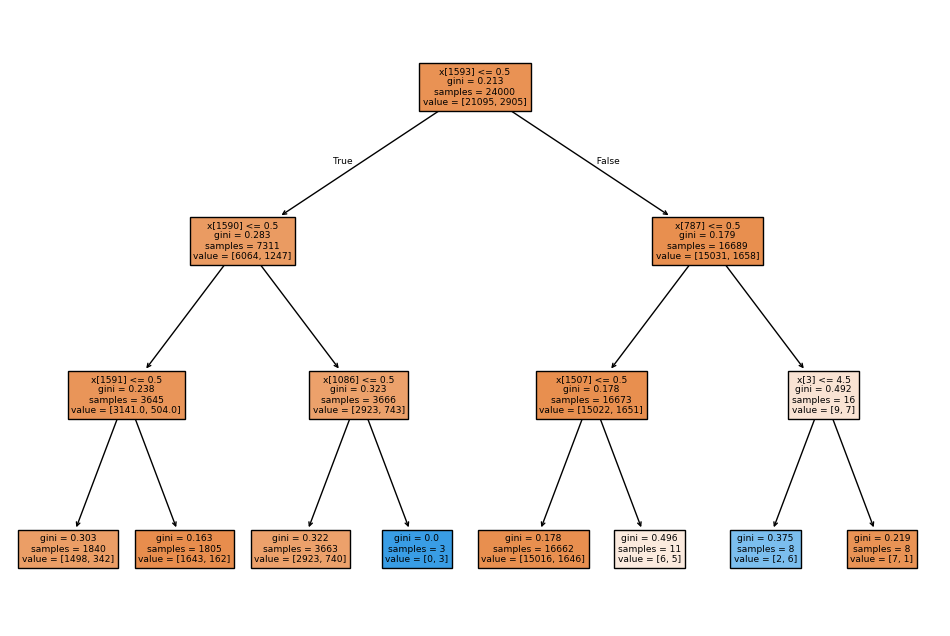

In [18]:
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

print("accuracy score: "+str(accuracy_score(y_test, pred)))
print("classification report: \n"+classification_report(y_test, pred))

plt.figure(figsize=(12,8))
plot_tree(dt, filled=True)
plt.show()

Decision Tree Results Interpretation

Although the Decision Tree achieved an accuracy of 0.8717, the classification report reveals that this high accuracy is mainly driven by the model correctly predicting the majority class (patients not readmitted).

For class 0 (not readmitted), the model performs very well, with a *recision of 0.87, recall of 1.00, and an F1-score of 0.93. This means the model is very effective at identifying patients who will not be readmitted.

However, the model performs very poorly for class 1 (readmitted patients). The recall is essentially 0.00, meaning the model almost never correctly identifies patients who are actually readmitted. This suggests that the Decision Tree is heavily biased toward predicting the majority class.

The macro average scores (precision 0.60, recall 0.50, F1-score 0.47) further highlight this imbalance in performance between the two classes.

These results indicate that while the Decision Tree is able to achieve high overall accuracy, it struggles to capture patterns that identify patients at risk of readmission. This limitation is likely influenced by the class imbalance in the dataset, where non-readmitted patients significantly outnumber readmitted ones.

7. Random Forest Model

Next, we train a Random Forest Classifier.

A Random Forest is an ensemble method that combines many decision trees instead of relying on a single one. This usually improves predictive performance and reduces overfitting.

In this implementation:
- multiple trees are used (`n_estimators=300`),
- class imbalance is handled with `class_weight="balanced"`,
- tree depth is limited to improve generalization.
- Stratified Cross-Validation is used instead of a single train-test split to obtain more robust performance estimates.

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

all_preds = []
all_true = []

for train_idx, test_idx in skf.split(X, y):
    X_train_fold, X_test_fold = X.iloc[train_idx], X.iloc[test_idx]
    y_train_fold, y_test_fold = y.iloc[train_idx], y.iloc[test_idx]

    rf = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced",
        max_depth=10
    )

    rf.fit(X_train_fold, y_train_fold)

    pred = rf.predict(X_test_fold)

    all_preds.extend(pred)
    all_true.extend(y_test_fold)

Random Forest Results

The Random Forest model is evaluated using the same metrics as the Decision Tree:
- predicted labels,
- accuracy score,
- classification report.

This allows a direct comparison between the two approaches.

In [24]:
print("accuracy score: " + str(accuracy_score(all_true, all_preds)) + "\n")
print("classification report:\n" + classification_report(all_true, all_preds))

accuracy score: 0.6875666666666667

classification report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80     26326
           1       0.18      0.42      0.25      3674

    accuracy                           0.69     30000
   macro avg       0.54      0.57      0.53     30000
weighted avg       0.81      0.69      0.73     30000



Feature Importance

Unlike a single decision tree, a random forest can also provide a more stable estimate of feature importance.

The output below highlights which variables contributed the most to the prediction task.

In [25]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
print("importance: \n" + str(importance.sort_values(ascending=False).head(10)))

importance: 
discharge_destination_Home                0.133208
discharge_destination_Rehab               0.086707
discharge_destination_Nursing_Facility    0.051687
bmi                                       0.043823
cholesterol                               0.034968
age                                       0.031113
length_of_stay                            0.027447
diabetes_No                               0.026314
diabetes_Yes                              0.023926
hypertension_Yes                          0.023249
dtype: float64


8. Model Comparison

Now that both models have been trained and evaluated, we can compare them.

Decision Tree
- simpler and easier to interpret,
- easier to visualize,
- may underperform because it relies on a single tree.

Random Forest
- usually more accurate,
- more robust to overfitting,
- provides feature importance,
- harder to interpret because it combines many trees.

In this project, the Random Forest model is expected to perform better because it captures more complex patterns in the data.

Although the Decision Tree achieved a relatively high accuracy of 0.8717, the classification report shows that this result can be misleading. The model performs extremely well when predicting the majority class (patients who are not readmitted), achieving a recall of 1.00, which means it correctly identifies nearly all of these cases.

However, the model performs very poorly for the minority class (patients who are readmitted). The recall for class 1 is essentially 0.00, meaning that the model almost never predicts a positive case. In practice, this means the Decision Tree tends to classify nearly every patient as not readmitted, which inflates the overall accuracy because the dataset contains many more negative cases than positive ones.

Because of this class imbalance,*accuracy alone is not a reliable measure of performance. Even though the model appears accurate overall, it fails at the more difficult and important task of identifying patients who are actually at risk of readmission.

A model with slightly lower overall accuracy may still be more useful if it is able to correctly detect positive cases (readmitted patients), since identifying these patients is the main goal of the prediction task.

9. Unsupervised Learning: Patient Clustering

In addition to supervised learning, we apply an unsupervised learning technique (K-Means clustering) to explore whether patients naturally form distinct groups based on their features.

The goal is to identify hidden patterns in the data and analyze whether certain clusters are associated with higher readmission rates.

   cluster
0        1
1        2
2        0
3        0
4        1


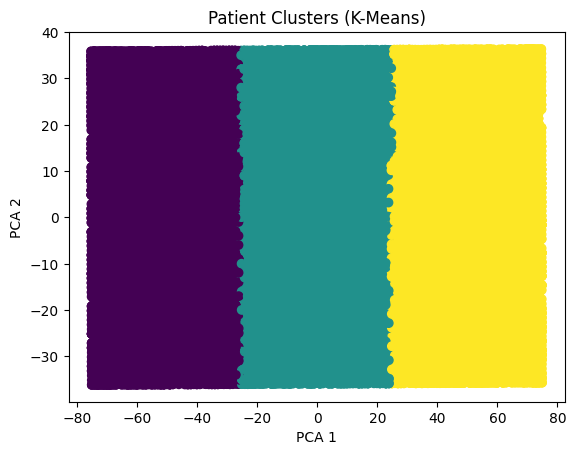

Patients in each cluster:
 cluster
2    10214
1     9910
0     9876
Name: count, dtype: int64 

Cluster profiles:
                age  cholesterol        bmi  medication_count  length_of_stay  \
cluster                                                                        
0        53.899149   174.536553  28.959194          5.029567        5.482078   
1        54.310696   224.626337  28.968527          4.985368        5.524420   
2        53.456041   274.920893  28.912160          5.021637        5.502154   

         readmitted_30_days  
cluster                      
0                  0.120292  
1                  0.122099  
2                  0.124927   

Clusters with higher readmission:
 cluster
0    0.120292
1    0.122099
2    0.124927
Name: readmitted_30_days, dtype: float64


In [33]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# remove target
X_unsupervised = X.copy()

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_unsupervised)

# add cluster labels
df['cluster'] = clusters

df.groupby('cluster')['readmitted_30_days'].mean()

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_unsupervised)

# assign cluster labels to the dataframe
df["cluster"] = clusters

# first rows with cluster labels
print(df[["cluster"]].head())

# plot clusters
plt.figure()
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Patient Clusters (K-Means)")

plt.show()

print("Patients in each cluster:\n", df["cluster"].value_counts(), "\n")

numeric_df = df.select_dtypes(include="number")

print("Cluster profiles:\n", numeric_df.groupby("cluster").mean(), "\n")

print("Clusters with higher readmission:\n", df.groupby("cluster")["readmitted_30_days"].mean())


10. Cluster Results

The clustering results show only minor differences in readmission rates across clusters (approximately 12.0%–12.5%). This suggests that the unsupervised grouping does not strongly separate patients based on readmission risk.

This outcome is expected, as K-Means clustering groups patients based on overall feature similarity rather than directly optimizing for the target variable. Therefore, while clusters may capture general patient profiles, they do not necessarily align with the factors that drive readmission.

Overall, this highlights that supervised models are more appropriate for predicting readmission, while clustering can still provide complementary insights into the structure of the dataset.

11. Conclusion

This notebook compared two models for predicting hospital readmissions: a Decision Tree and a Random Forest.

The Decision Tree achieved a relatively high accuracy (around 0.87), but the classification report revealed that the model almost always predicted the majority class (patients not readmitted). As a result, it failed to correctly identify most patients who were actually readmitted. This demonstrates how accuracy alone can be misleading in imbalanced classification problems.

In contrast, the Random Forest model, while sometimes achieving slightly lower overall accuracy, was able to detect more positive cases (readmitted patients). This makes it more useful for the task, since identifying patients at risk of readmission is the main goal of the prediction.

In addition, an unsupervised clustering approach (K-Means) was applied to explore potential structure in the data. The results showed only small differences in readmission rates across clusters, suggesting that natural groupings of patients do not strongly correspond to readmission risk. This reinforces the importance of supervised learning methods for this task.

Overall, the comparison highlights an important lesson in machine learning: models should not be evaluated using accuracy alone, especially when dealing with imbalanced datasets. Metrics such as recall and F1-score provide a more complete picture of model performance.